### TIME SERIES

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle


In [4]:
sm = pd.read_csv("soil_moisture_data.csv")

In [5]:
### check the first first rows
sm.head()

,time,latitude,longitude,clay_content,sand_content,silt_content,sm_aux,sm_tgt
0,2013-01-03,54.875,9.125,5.0,86.0,9.0,0.454120,0.53
1,2013-01-05,54.875,9.125,5.0,86.0,9.0,0.437102,0.44
2,2013-01-07,54.875,9.125,5.0,86.0,9.0,0.412978,0.42
3,2013-01-08,54.875,9.125,5.0,86.0,9.0,0.378734,0.55
4,2013-01-09,54.875,9.125,5.0,86.0,9.0,0.350740,0.46


In [6]:
sm.shape

(321584, 8)

In [7]:
#### display columns
sm.columns

Index(['time', 'latitude', 'longitude', 'clay_content', 'sand_content',
       'silt_content', 'sm_aux', 'sm_tgt'],
      dtype='object')

In [8]:
### check for unique regions
sm[["latitude", "longitude"]].nunique()

latitude     28
longitude    56
dtype: int64

In [9]:
#### group the longitude by latitude
sm.groupby(["latitude", "longitude"]).size()

latitude  longitude
48.125    2.125        297
          2.375        314
          2.625        308
          2.875        307
          3.125        307
                      ... 
54.625    9.625        187
          9.875         57
54.875    9.125        263
          9.375        213
          9.875          2
Length: 1166, dtype: int64

In [10]:
### Focus on one region
lat = 48.125
long = 2.125

In [11]:
#### Extract data for the cordinate (48.125, 2.125)
sm_df = sm[(sm["latitude"] == lat) & (sm["longitude"] == long)]

In [12]:
### shape of new data
sm_df.shape

(297, 8)

In [13]:
sm_df.dtypes

time             object
latitude        float64
longitude       float64
clay_content    float64
sand_content    float64
silt_content    float64
sm_aux          float64
sm_tgt          float64
dtype: object

In [14]:
### convert time(column) to datetime
sm_df["time"] = pd.to_datetime(sm_df["time"])

C:\Users\Blossom Academy\AppData\Local\Temp\ipykernel_31824\3978406151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sm_df["time"] = pd.to_datetime(sm_df["time"])


In [15]:
#### make sure your time column is in a specific order ideal for time tracking
### We will sort in ascending order
sm_df["time"] = sm_df["time"].sort_values()

C:\Users\Blossom Academy\AppData\Local\Temp\ipykernel_31824\2042833959.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sm_df["time"] = sm_df["time"].sort_values()


In [16]:
### set the time column as the index of the dataset
sm_df = sm_df.set_index("time")

In [17]:
sm_df.head()

,latitude,longitude,clay_content,sand_content,silt_content,sm_aux,sm_tgt
time,,,,,,,
2013-01-02,48.125,2.125,35.0,14.0,51.0,0.322952,0.53
2013-01-07,48.125,2.125,35.0,14.0,51.0,0.348089,0.55
2013-01-16,48.125,2.125,35.0,14.0,51.0,0.234732,0.59
2013-01-17,48.125,2.125,35.0,14.0,51.0,0.184927,0.39
2013-01-19,48.125,2.125,35.0,14.0,51.0,0.122942,0.54


In [18]:
#### Assume we are tracking the soil moisture everyday
sm_d = sm_df.asfreq("D")

In [19]:
sm_d.shape

(361, 7)

In [20]:
sm_d.isna().sum()

latitude        64
longitude       64
clay_content    64
sand_content    64
silt_content    64
sm_aux          64
sm_tgt          64
dtype: int64

In [21]:
#### fill in missing values
sm_d["sm_tgt"] = sm_d["sm_tgt"].interpolate()

In [22]:
sm_d.isna().sum()

latitude        64
longitude       64
clay_content    64
sand_content    64
silt_content    64
sm_aux          64
sm_tgt           0
dtype: int64

In [23]:
#### confirm monotonic increasing
sm_d.index.is_monotonic_increasing

True

In [24]:
### select the target variable
y = sm_d["sm_tgt"]

In [25]:
y

time
2013-01-02    0.530
2013-01-03    0.534
2013-01-04    0.538
2013-01-05    0.542
2013-01-06    0.546
              ...  
2013-12-24    0.550
2013-12-25    0.550
2013-12-26    0.570
2013-12-27    0.590
2013-12-28    0.570
Freq: D, Name: sm_tgt, Length: 361, dtype: float64

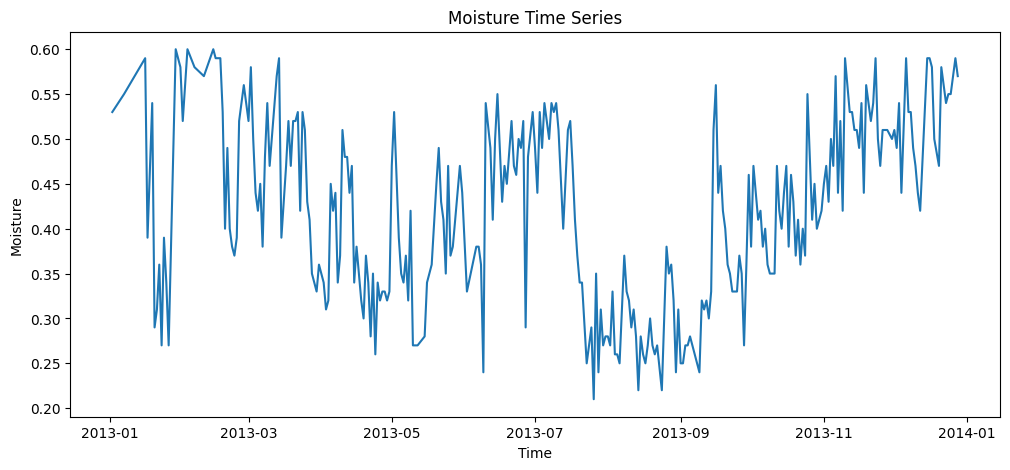

In [26]:
#### Visualize the data and check for seasonality, trends, cycle, and or noise
plt.figure(figsize=(12,5))
plt.plot(y)
plt.title("Moisture Time Series")
plt.xlabel("Time")
plt.ylabel("Moisture")
plt.show()

## Test for Stationarity (ADF)
### Hypothesis
- H0: The series is non-stationary
- H1: The series is stationary

In [27]:
#### test for stationarity
result = adfuller(y)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.864283925553032
p-value: 0.0023140003188879686


- Since p-value < 0.05, we will reject the Null hypothesis and go with the claim that the series is stationary


## Test for Stationarity (KPSS)
### Hypothesis
- H0: The series is stationary
- H1: The series is non-stationary

In [28]:
stat, p_value, lags, crit = kpss(y, regression='c')

print("KPSS Statistic:", stat)
print("p-value:", p_value)
print("lags:", lags)
print("critical values:", crit)

KPSS Statistic: 0.44246457377138454
p-value: 0.058851476822679084
lags: 11
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


- Since p-value > 0.05, we will fail to reject the Null hypothesis and go with the claim that the series is stationary

#### ACF & PACF plot

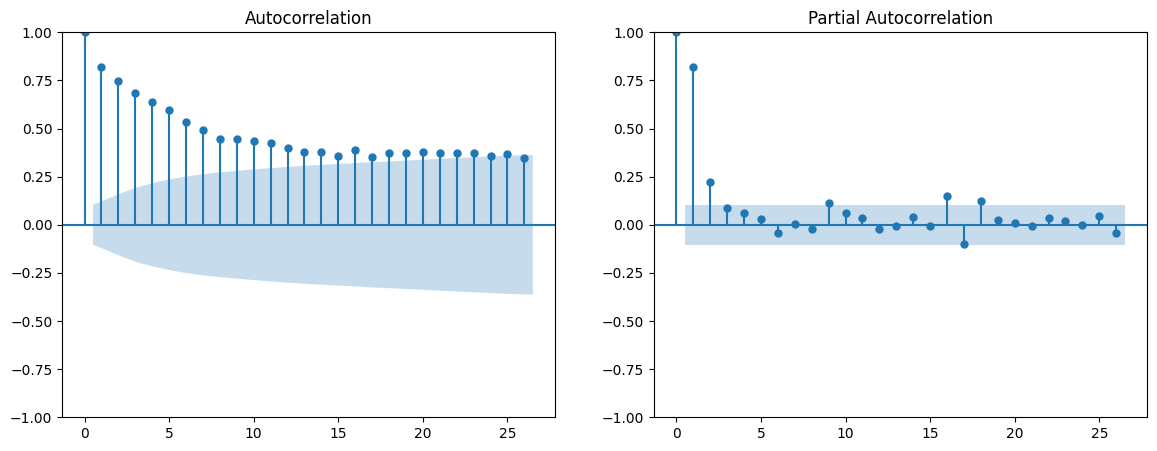

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(y, ax=axes[0])
plot_pacf(y, ax=axes[1])

plt.show()

In [30]:
#### Train and test split
train_size = int(len(y) * 0.8)

train = y[:train_size]
test = y[train_size:]

In [31]:
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 288
Test size: 73


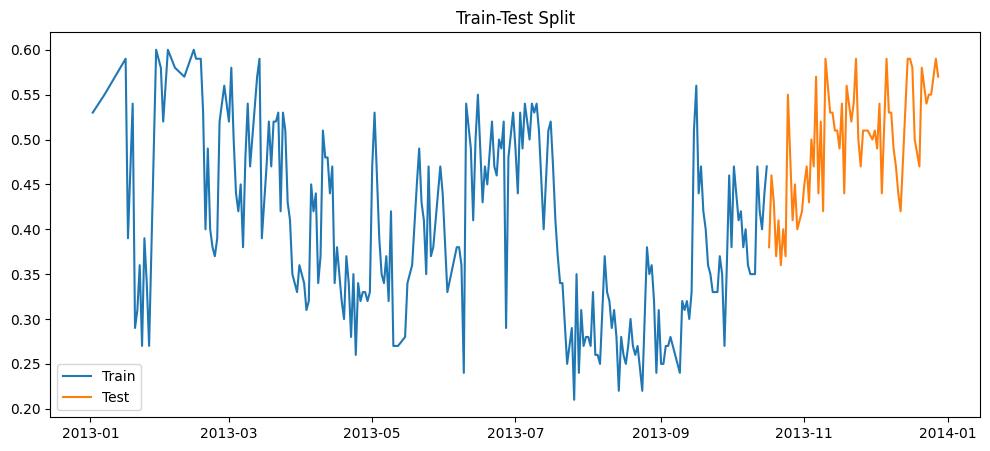

In [32]:
#### plot the train and test data
plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.legend()
plt.title("Train-Test Split")
plt.show()

In [33]:
#### Initialize the model
model = ARIMA(train, order=(4,0,0))

In [34]:
model_fit = model.fit()

In [35]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 sm_tgt   No. Observations:                  288
Model:                 ARIMA(4, 0, 0)   Log Likelihood                 410.583
Date:                Sun, 31 May 2026   AIC                           -809.165
Time:                        20:47:05   BIC                           -787.188
Sample:                    01-02-2013   HQIC                          -800.358
                         - 10-16-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4173      0.027     15.231      0.000       0.364       0.471
ar.L1          0.6460      0.054     11.945      0.000       0.540       0.752
ar.L2          0.1083      0.072      1.495      0.1

In [36]:
### use the model for prediction
forecast = model_fit.forecast(steps=len(test))

In [37]:
print(forecast.head())

2013-10-17    0.452508
2013-10-18    0.446867
2013-10-19    0.445472
2013-10-20    0.443809
2013-10-21    0.441381
Freq: D, Name: predicted_mean, dtype: float64


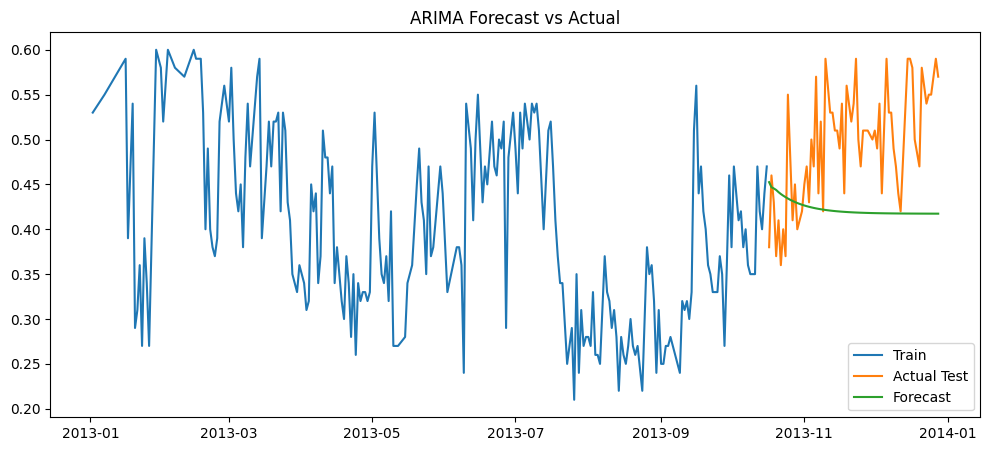

In [38]:
#### plot of predicted and actual (train and test)

plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Actual Test')
plt.plot(forecast, label='Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [39]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.08579587876569796
RMSE: 0.09937347956757077


In [40]:
#### save the best model
with open('arima_model.pkl', 'wb') as f:
    pickle.dump(model_fit, f)

In [50]:
#### Initialize ARIMA model
#### Initialize the model
model_1 = ARIMA(train, order=(1,0,0))

In [51]:
model_1_fit = model_1.fit()

In [52]:
print(model_1_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 sm_tgt   No. Observations:                  288
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 403.499
Date:                Sun, 31 May 2026   AIC                           -800.998
Time:                        21:05:31   BIC                           -790.009
Sample:                    01-02-2013   HQIC                          -796.594
                         - 10-16-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4145      0.020     21.047      0.000       0.376       0.453
ar.L1          0.8249      0.043     18.995      0.000       0.740       0.910
sigma2         0.0035      0.000     13.027      0.0

In [53]:
### use the model for prediction
forecast_1 = model_1_fit.forecast(steps=len(test))

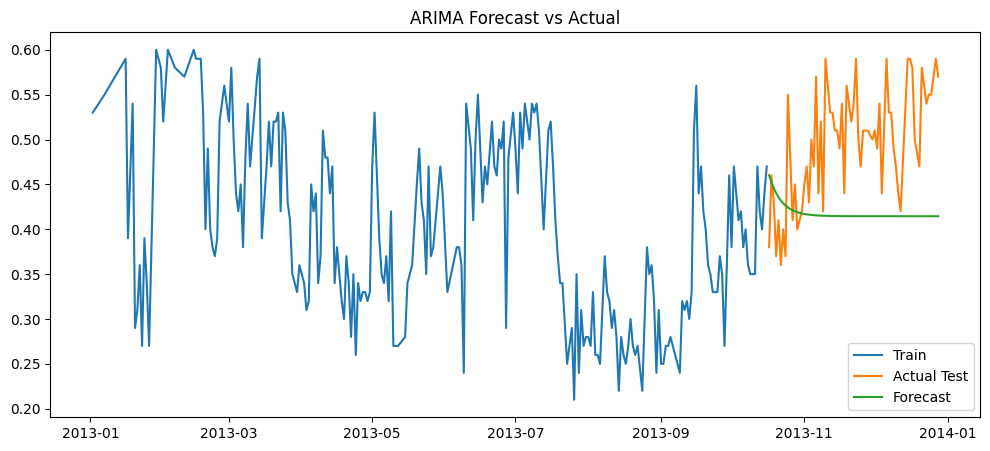

In [54]:
#### plot of predicted and actual (train and test)

plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Actual Test')
plt.plot(forecast_1, label='Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [55]:
mae = mean_absolute_error(test, forecast_1)
rmse = np.sqrt(mean_squared_error(test, forecast_1))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.08874705855015498
RMSE: 0.1025952012059265


In [56]:
model_fit.aic

np.float64(-809.1654633818398)